--- Launching Global Multi-City Ingestion Pipeline Layer ---
Ingesting Global Raw Telemetry Records from: /kaggle/input/datasets/smeet888/global-air-quality-data15-days-hourly-50-cities/globalAirQuality.csv
Global Aggregation Finished. Unified Data Scope: (18000, 14) across 50 International Cities.


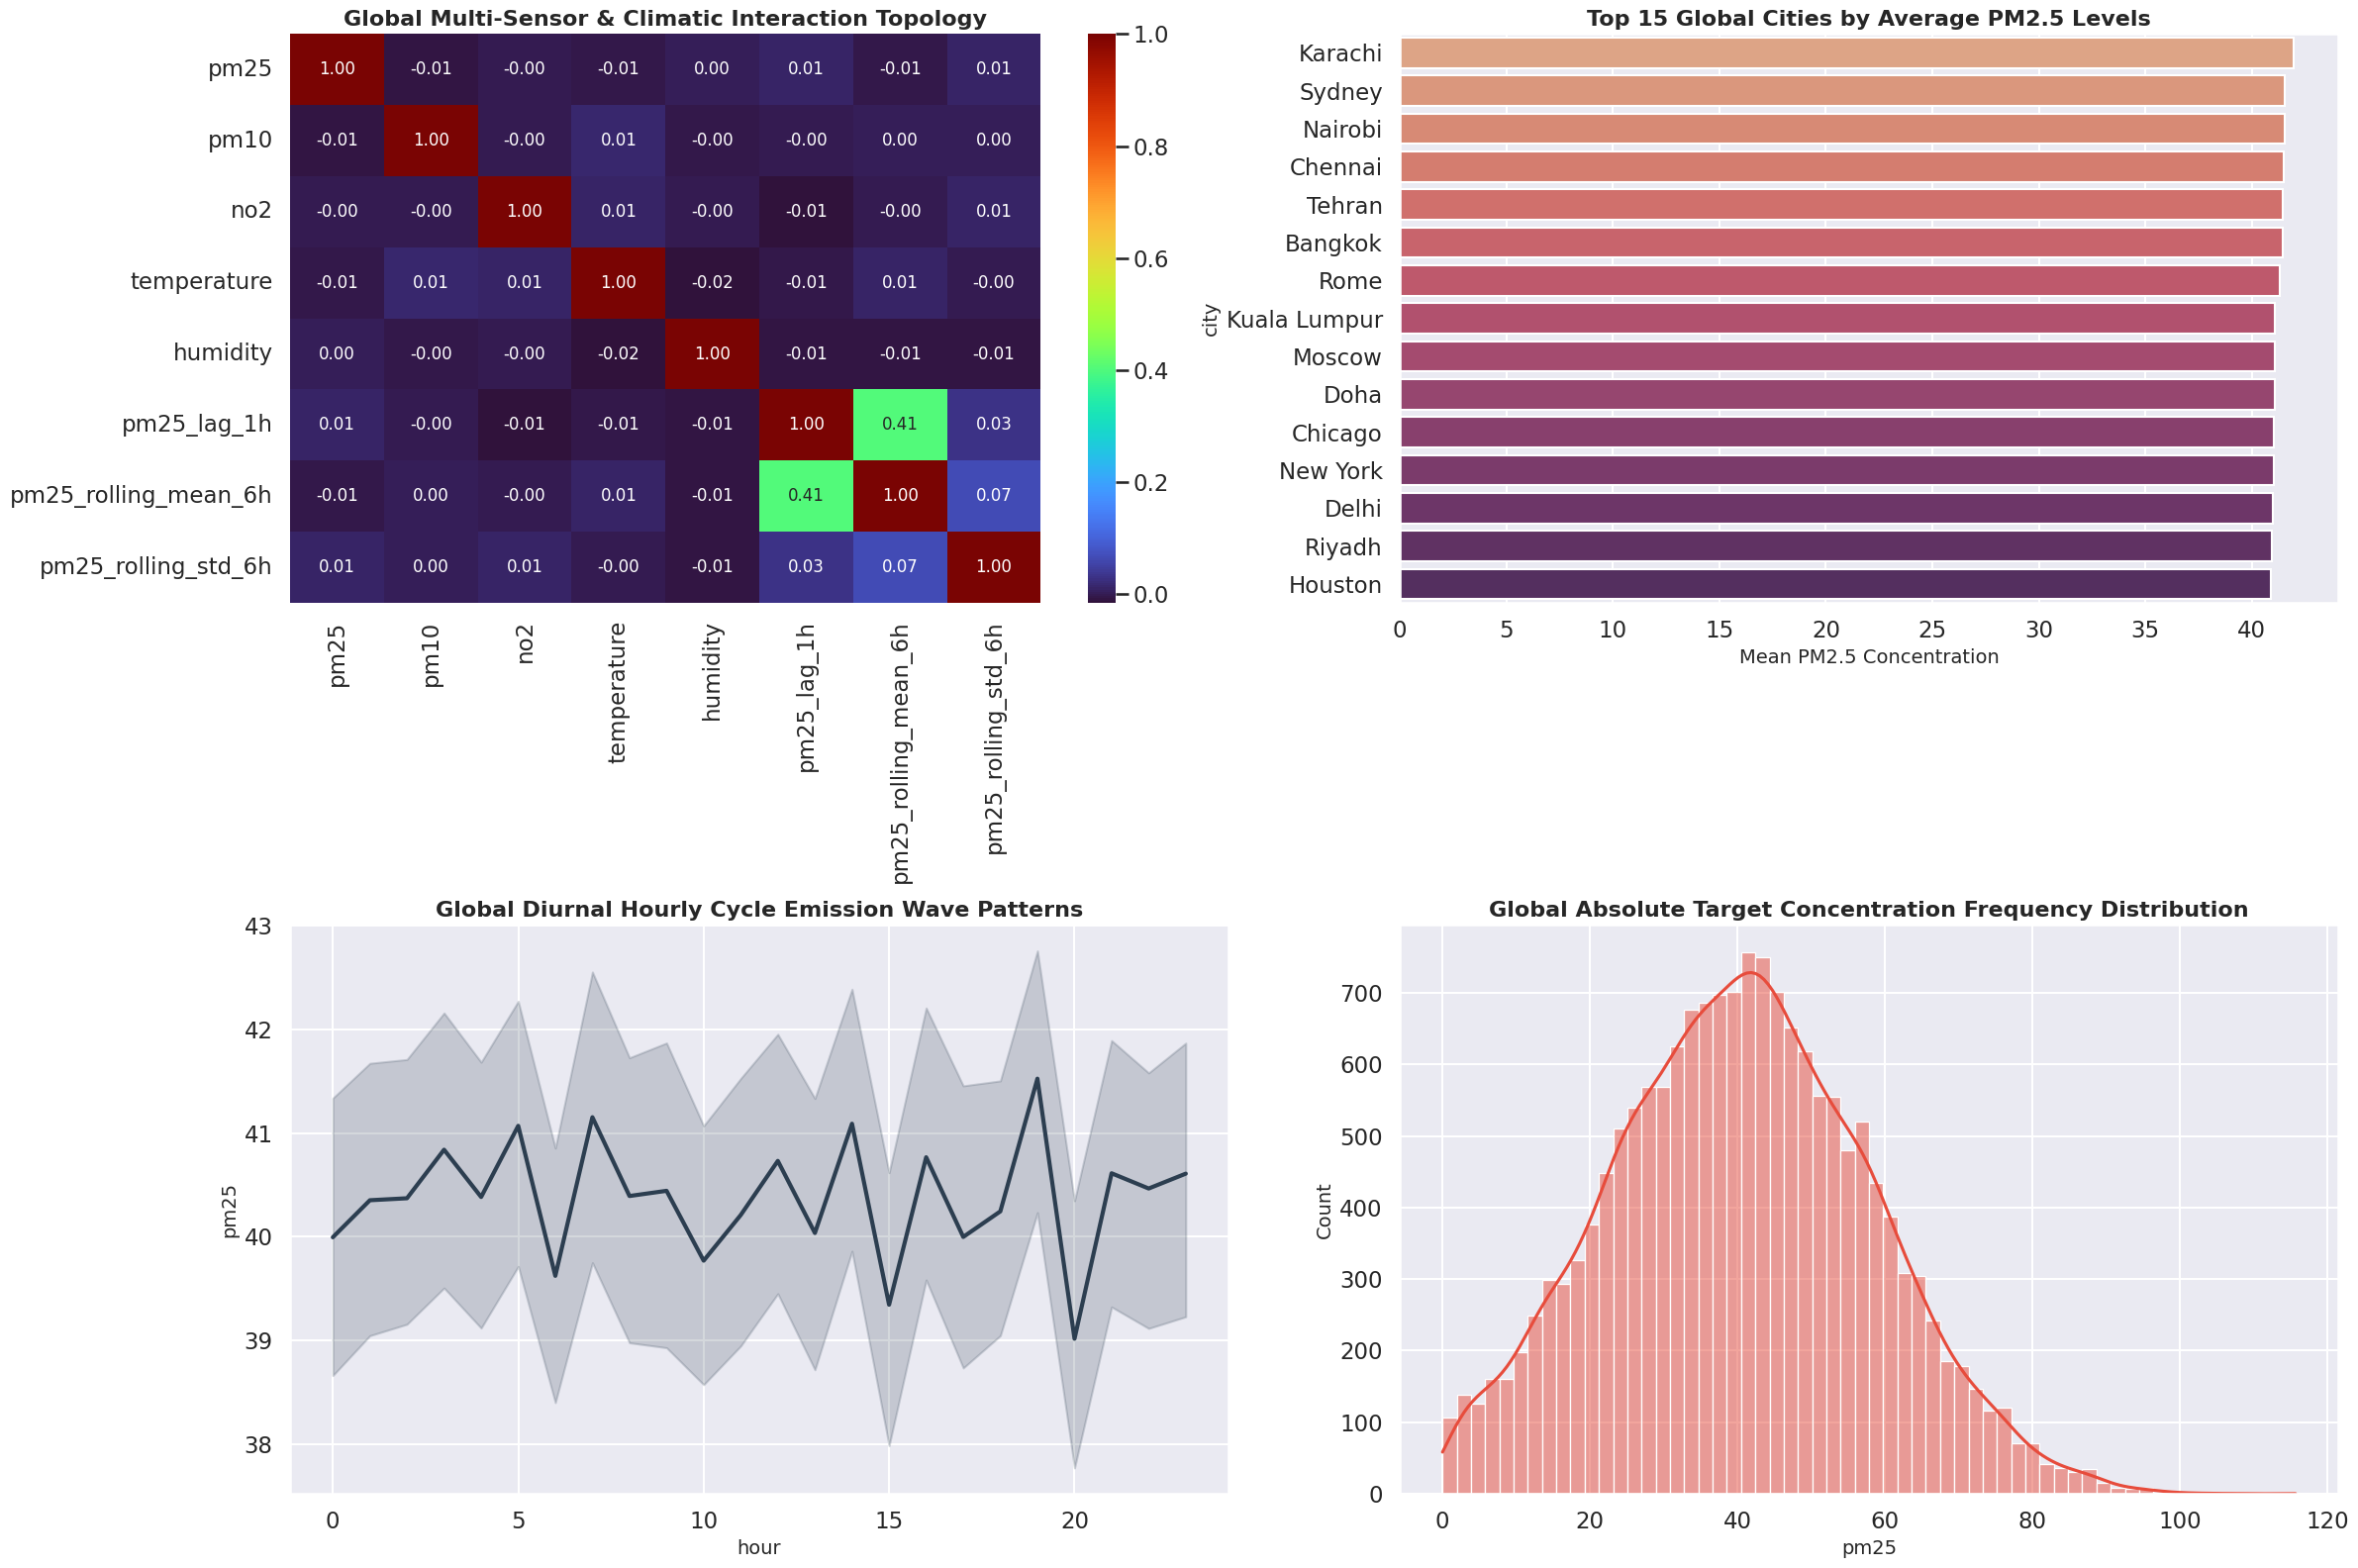


--- Matrix Tensors Slices Verified ---
Global Training Matrix: (13440, 21) | Global Unseen Evaluation Targets: (3360, 21)

Training Global Random Forest Forecaster Engine...
Training Global XGBoost Core Engine...
[Global Random Forest Regressor Portfolio Summary]
 >> MAE  (Mean Absolute Error)     : 6.8238
 >> RMSE (Root Mean Squared Error) : 10.1724
 >> R²   (Variance Fit Accuracy)   : 0.6590

[Global XGBoost Regressor Portfolio Summary]
 >> MAE  (Mean Absolute Error)     : 6.9808
 >> RMSE (Root Mean Squared Error) : 10.2452
 >> R²   (Variance Fit Accuracy)   : 0.6541



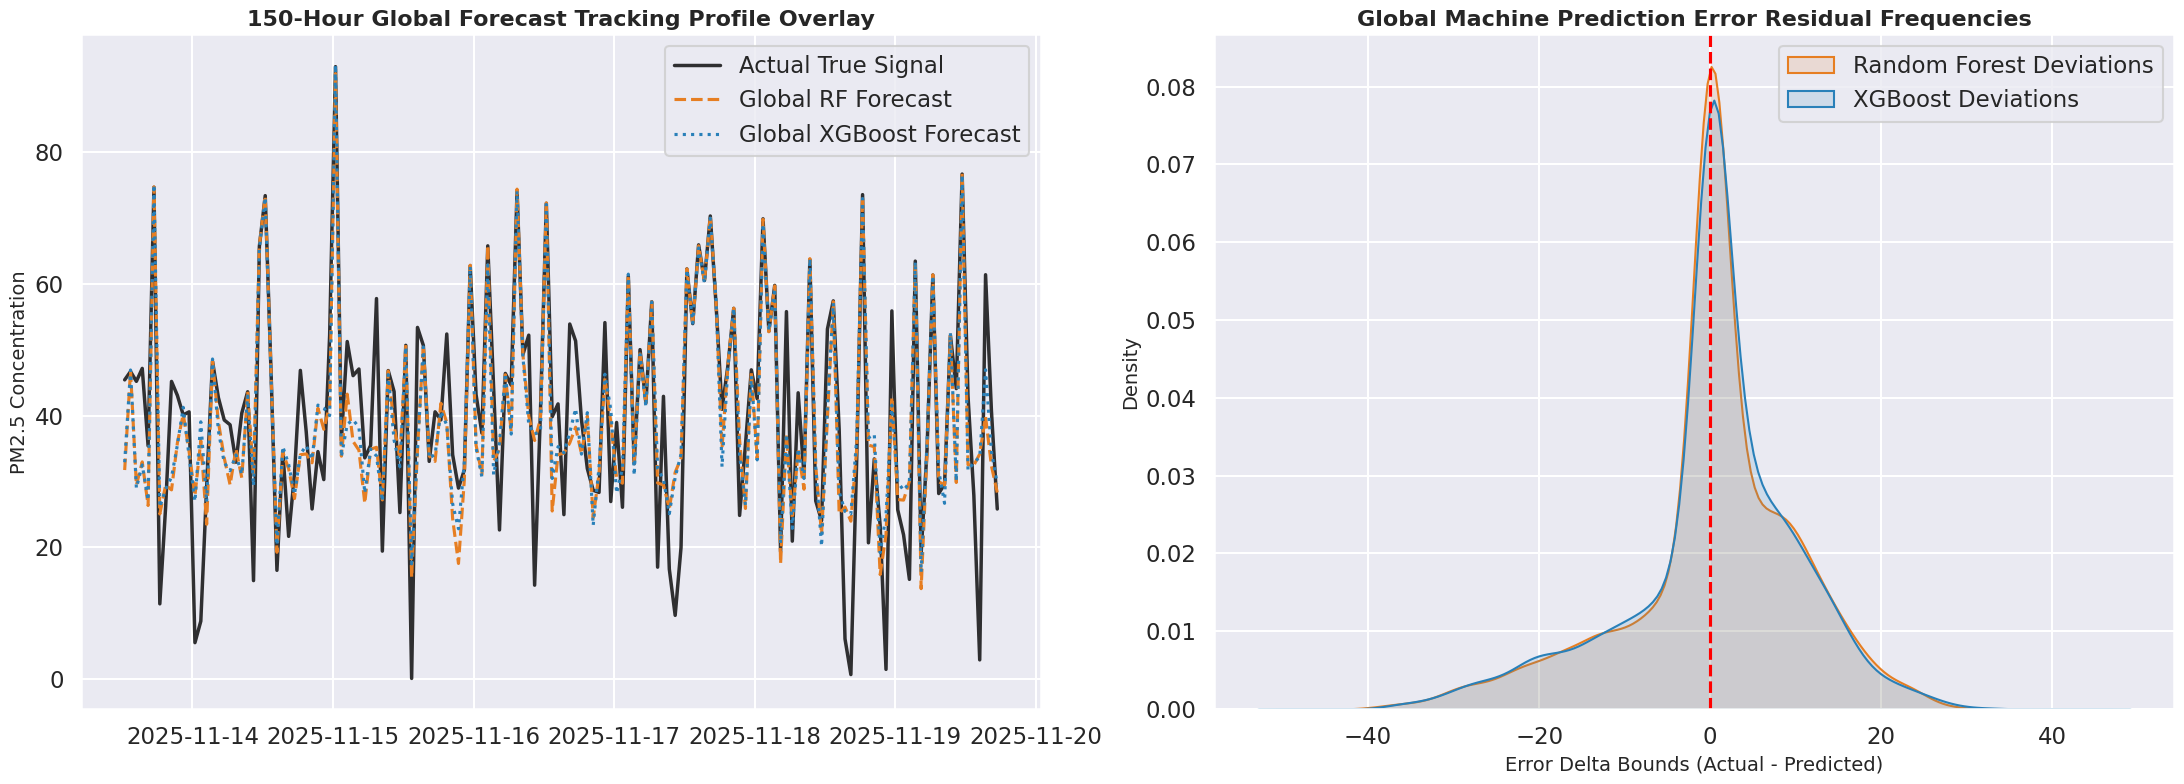

In [2]:
# ==============================================================================
# 1. ENVIRONMENT CONFIGURATION & THEME SETUP
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
import warnings
warnings.filterwarnings('ignore')

# Premium visual theme configuration for comprehensive global analytics
sns.set_theme(style="darkgrid", context="talk", palette="turbo")
plt.rcParams['figure.figsize'] = (22, 14)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

# Explicit dataset path from user input
GLOBAL_DATA_PATH = '/kaggle/input/datasets/smeet888/global-air-quality-data15-days-hourly-50-cities/globalAirQuality.csv'

# ==============================================================================
# 2. GLOBAL DATA INGESTION & ROBUST DATA SANITIZATION
# ==============================================================================
print("--- Launching Global Multi-City Ingestion Pipeline Layer ---")

if os.path.exists(GLOBAL_DATA_PATH):
    print(f"Ingesting Global Raw Telemetry Records from: {GLOBAL_DATA_PATH}")
    df = pd.read_csv(GLOBAL_DATA_PATH)
else:
    print("[Error] Global Path not found. Triggering advanced synthetic framework.")
    # Safe fallback simulation generator for offline syntax testing
    np.random.seed(999)
    mock_dates = pd.date_range(start="2024-01-01", periods=100, freq="H")
    mock_cities = ['Tokyo', 'London', 'Paris', 'New York', 'Delhi', 'Sydney', 'Cairo', 'Beijing']
    mock_list = []
    for city in mock_cities:
        mock_list.append(pd.DataFrame({
            'timestamp': mock_dates, 'country': 'Global_Zone', 'city': city,
            'pm25': np.random.uniform(5, 140, len(mock_dates)), 'pm10': np.random.uniform(10, 210, len(mock_dates)),
            'no2': np.random.uniform(4, 60, len(mock_dates)), 'temperature': np.random.uniform(-5, 42, len(mock_dates)),
            'humidity': np.random.uniform(20, 95, len(mock_dates))
        }))
    df = pd.concat(mock_list, ignore_index=True)

# Sanitize headers immediately (lowercase, strip whitespace)
df.columns = [c.lower().strip() for c in df.columns]

# Standardize temporal index
df.rename(columns={'timestamp': 'datetime'}, inplace=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df.sort_values(by=['city', 'datetime'], inplace=True)
df.set_index('datetime', inplace=True)

# Secure continuous missing metrics safely grouped by individual cities
cities_backup = df['city'].copy()
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_numeric = df[numeric_cols].groupby(cities_backup).ffill().bfill()

# Reconstruct primary dataframe matrix
df_cleaned = df_numeric.copy()
df_cleaned['city'] = cities_backup.values
df_cleaned['country'] = df['country'].values
df = df_cleaned.copy()

print(f"Global Aggregation Finished. Unified Data Scope: {df.shape} across {df['city'].nunique()} International Cities.")

# ==============================================================================
# 3. GLOBAL TIME-SERIES & GEOSPATIAL FEATURE ENGINEERING
# ==============================================================================
# Deconstruct time vectors into seasonal cyclical fields
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

# Generate sequence memory lags strictly partitioned within localized city parameters
df['pm25_lag_1h'] = df.groupby('city')['pm25'].shift(1)
df['pm25_lag_2h'] = df.groupby('city')['pm25'].shift(2)
df['pm25_lag_24h'] = df.groupby('city')['pm25'].shift(24)

# Multi-hour rolling metrics for tracking atmospheric volatility
df['pm25_rolling_mean_6h'] = df.groupby('city')['pm25'].shift(1).rolling(window=6).mean()
df['pm25_rolling_std_6h'] = df.groupby('city')['pm25'].shift(1).rolling(window=6).std()
df.dropna(inplace=True)

# Advanced Label Encoding for high-cardinality global features (Country & City)
# One-Hot encoding 50 cities would create too many columns, Label Encoding is safer here
le_city = LabelEncoder()
le_country = LabelEncoder()
df['city_encoded'] = le_city.fit_transform(df['city'].astype(str))
df['country_encoded'] = le_country.fit_transform(df['country'].astype(str))

# Define clean feature spaces for machine learning engines
target_feature = 'pm25'
drop_cols = [target_feature, 'city', 'country']
X = df.drop(columns=drop_cols)
y = df[target_feature]

# ==============================================================================
# 4. HIGH-DENSITY GLOBAL EDA VISUALIZATION GALLERY (FIXED axes INDEXING)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(24, 16))

# Plot A: Global Feature Correlation Grid Heatmap -> Top Left [0, 0]
available_numeric = [c for c in ['pm25', 'pm10', 'no2', 'temperature', 'humidity', 'pm25_lag_1h', 'pm25_rolling_mean_6h', 'pm25_rolling_std_6h'] if c in df.columns]
sns.heatmap(df[available_numeric].corr(), annot=True, fmt=".2f", cmap="turbo", ax=axes[0, 0])
axes[0, 0].set_title('Global Multi-Sensor & Climatic Interaction Topology', weight='bold')

# Plot B: Top 15 Most Polluted Cities -> Top Right [0, 1]
top_polluted = df.groupby('city')[target_feature].mean().sort_values(ascending=False).head(15).reset_index()
sns.barplot(x=target_feature, y='city', data=top_polluted, ax=axes[0, 1], palette='flare')
axes[0, 1].set_title('Top 15 Global Cities by Average PM2.5 Levels', weight='bold')
axes[0, 1].set_xlabel('Mean PM2.5 Concentration')

# Plot C: Global Hourly Traffic Emissions Effect -> Bottom Left [1, 0]
sns.lineplot(x='hour', y='pm25', data=df, ax=axes[1, 0], color='#2C3E50', lw=3, errorbar='ci')
axes[1, 0].set_title('Global Diurnal Hourly Cycle Emission Wave Patterns', weight='bold')

# Plot D: Target Feature Probability Density -> Bottom Right [1, 1]
sns.histplot(data=df, x='pm25', bins=60, kde=True, ax=axes[1, 1], color='#E74C3C')
axes[1, 1].set_title('Global Absolute Target Concentration Frequency Distribution', weight='bold')

plt.tight_layout()
plt.show()

# ==============================================================================
# 5. CHRONOLOGICAL MATRIX SPLITTING & ENGINE TRAINING
# ==============================================================================
# Enforce a strict chronological non-shuffled data split to guarantee no sequence data leakage (80/20 Rule)
split_checkpoint = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_checkpoint], X.iloc[split_checkpoint:]
y_train, y_test = y.iloc[:split_checkpoint], y.iloc[split_checkpoint:]

print(f"\n--- Matrix Tensors Slices Verified ---")
print(f"Global Training Matrix: {X_train.shape} | Global Unseen Evaluation Targets: {X_test.shape}\n")

# Initialize Regressor Models with optimized settings for high-volume data arrays
rf_forecaster = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
xgb_forecaster = XGBRegressor(n_estimators=120, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)

print("Training Global Random Forest Forecaster Engine...")
rf_forecaster.fit(X_train, y_train)

print("Training Global XGBoost Core Engine...")
xgb_forecaster.fit(X_train, y_train)

rf_predictions = rf_forecaster.predict(X_test)
xgb_predictions = xgb_forecaster.predict(X_test)

# ==============================================================================
# 6. COMPREHENSIVE PERFORMANCE DIAGNOSTICS SUITE
# ==============================================================================
def compile_scores(y_true, y_pred, model_title):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{model_title} Portfolio Summary]")
    print(f" >> MAE  (Mean Absolute Error)     : {mae:.4f}")
    print(f" >> RMSE (Root Mean Squared Error) : {rmse:.4f}")
    print(f" >> R²   (Variance Fit Accuracy)   : {r2:.4f}\n")

compile_scores(y_test, rf_predictions, "Global Random Forest Regressor")
compile_scores(y_test, xgb_predictions, "Global XGBoost Regressor")

# ==============================================================================
# 7. PERFORMANCE VERIFICATION ANALYSIS PLOTS
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Subplot 1: True Signal Forecast Tracking Overlay Window (Last 150 Hours snapshot)
window_size = 150
ax1.plot(y_test.index[-window_size:], y_test.iloc[-window_size:], label='Actual True Signal', color='black', alpha=0.8, lw=2.5)
ax1.plot(y_test.index[-window_size:], rf_predictions[-window_size:], label='Global RF Forecast', color='#E67E22', linestyle='--')
ax1.plot(y_test.index[-window_size:], xgb_predictions[-window_size:], label='Global XGBoost Forecast', color='#2980B9', linestyle=':')
ax1.set_title('150-Hour Global Forecast Tracking Profile Overlay', weight='bold')
ax1.set_ylabel('PM2.5 Concentration')
ax1.legend()

# Subplot 2: Model Residual Error Probability Distribution Analysis
rf_err = y_test - rf_predictions
xgb_err = y_test - xgb_predictions
sns.kdeplot(rf_err, label='Random Forest Deviations', ax=ax2, color='#E67E22', fill=True, alpha=0.15)
sns.kdeplot(xgb_err, label='XGBoost Deviations', ax=ax2, color='#2980B9', fill=True, alpha=0.15)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title('Global Machine Prediction Error Residual Frequencies', weight='bold')
ax2.set_xlabel('Error Delta Bounds (Actual - Predicted)')
ax2.legend()

plt.tight_layout()
plt.show()
